# Forward model first attempt

First attempt at buidling a forward model. This is creating a v simple model for forwards, which I can then build other functions/methods around rather than being state of the art.

## Checklist for notebook
- [X] Filter data to just forwards
- [ ] Use same features as defenders + goals scored?
- [ ] Create a midfielder experiment in mlflow and train a simple model on initial data 

In [1]:
from matplotlib import pyplot as plt
import mlflow
import polars as pl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from fantasy_football.constants import DATA_FOLDER, MODELS_FOLDER, MLFLOW_DB_PATH
from fantasy_football.processors.team_features import merge_team_conceded, merge_team_scored
from fantasy_football.processors.player_features import merge_player_conceded, get_player_rolling_minutes, merge_player_goals_scored, merge_player_assists, merge_player_yellow_cards, merge_player_red_cards
from fantasy_football.processors.gk_features import merge_gk_rolling_saves
from fantasy_football.models.evaluation import PlayerModelMetrics
from fantasy_football.models.utils import save_model, save_pipeline

In [2]:
player_data_filepath = DATA_FOLDER.joinpath("raw","cleaned_merged_seasons.csv")
player_data = pl.read_csv(player_data_filepath, try_parse_dates=True).sort("kickoff_time")

player_data.head()

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64
"""2016-17""","""Andrew Robertson""","""DEF""",null,0,0,14,0,1.8,152,4,1,0,1.7,14.8,2016-08-13 11:30:00 UTC,90,8,"""Leicester""",0,0,0,0,1,0,32036,1.0,2.0,0.0,2,0,0,0,45,true,0,1
"""2016-17""","""Benjamin Chilwell""","""DEF""",null,0,0,0,0,0.0,496,4,0,0,0.0,0.0,2016-08-13 11:30:00 UTC,0,7,"""Hull""",0,0,0,0,1,0,8192,1.0,2.0,0.0,0,0,0,0,45,false,0,1
"""2016-17""","""Christian Fuchs""","""DEF""",null,0,0,17,0,13.8,168,4,2,0,5.6,25.4,2016-08-13 11:30:00 UTC,90,7,"""Hull""",0,0,0,0,1,0,418306,1.0,2.0,17.0,0,0,0,0,55,false,1,1
"""2016-17""","""Daniel Amartey""","""DEF""",null,0,0,6,0,10.5,182,4,0,0,1.9,8.0,2016-08-13 11:30:00 UTC,23,7,"""Hull""",0,0,0,0,1,0,2315,1.0,2.0,0.0,1,0,0,0,45,false,0,1
"""2016-17""","""Demarai Gray""","""MID""",null,1,0,16,0,2.9,181,4,2,0,2.2,1.6,2016-08-13 11:30:00 UTC,67,7,"""Hull""",0,0,0,0,1,0,19681,1.0,2.0,17.0,5,0,0,0,50,false,0,1


In [4]:
fwd_data = player_data.filter(pl.col("position") == "FWD")
fwd_data.head()

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64
"""2016-17""","""Jamie Vardy""","""FWD""",null,0,0,1,0,22.5,184,4,2,0,5.8,3.2,2016-08-13 11:30:00 UTC,90,7,"""Hull""",0,0,0,0,1,0,864018,1.0,2.0,32.0,2,0,0,0,100,false,0,1
"""2016-17""","""Andre Gray""","""FWD""",null,0,0,-3,0,2.3,68,1,1,0,4.3,0.0,2016-08-13 14:00:00 UTC,90,16,"""Swansea""",0,0,0,0,1,0,410883,1.0,0.0,42.0,2,0,0,0,65,true,0,1
"""2016-17""","""Ashley Barnes""","""FWD""",null,0,0,0,0,0.0,70,1,0,0,0.0,0.0,2016-08-13 14:00:00 UTC,0,16,"""Swansea""",0,0,0,0,1,0,3649,1.0,0.0,0.0,0,0,0,0,45,true,0,1
"""2016-17""","""Charlie Austin""","""FWD""",null,0,0,2,0,1.0,314,7,0,0,1.0,0.0,2016-08-13 14:00:00 UTC,8,18,"""Watford""",0,0,0,0,1,0,60547,1.0,1.0,11.0,1,0,0,0,65,true,0,1
"""2016-17""","""Connor Wickham""","""FWD""",null,0,0,1,0,8.3,122,2,1,0,1.7,0.0,2016-08-13 14:00:00 UTC,90,19,"""West Brom""",0,0,0,0,1,0,43933,1.0,0.0,13.0,2,0,0,0,60,true,0,1


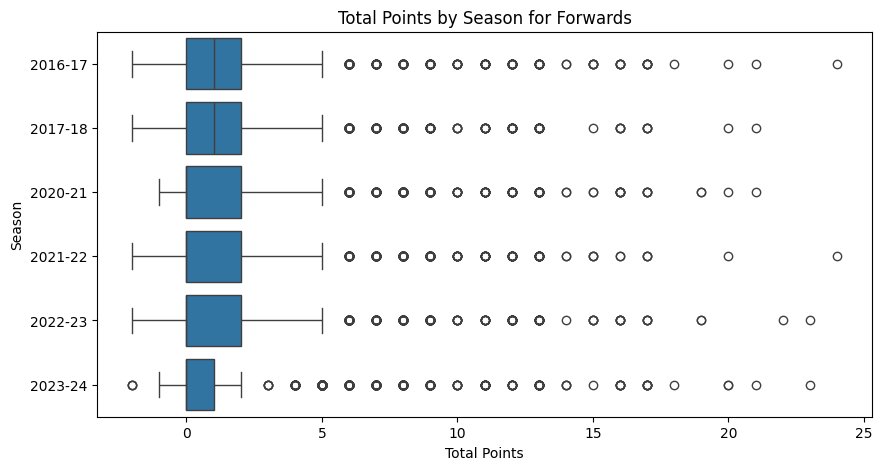

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=fwd_data, y="season_x", x="total_points", ax=ax)

ax.set(
    xlabel="Total Points",
    ylabel="Season",
    title="Total Points by Season for Forwards"
)

plt.show()


In [ ]:
# minutes
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(fwd_data["minutes"], fwd_data["total_points"], alpha=0.5)

ax.set(
    xlabel="Minutes",
    ylabel="Total Points",
    title="Minutes vs Total Points for Goalkeepers"
)

plt.show()